# Decision Tree Classification — Adult Income Dataset

**Task:** Binary classification — predict whether a person earns `>50K` or `<=50K` per year  
**Dataset:** UCI Adult Income (pre-cleaned train/test splits)  
**Approach:** Iterative refinement — baseline → hyperparameter search → custom balance-score search → cost-complexity pruning → threshold optimisation

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Checks](#2)
3. [Baseline Decision Tree](#3)
4. [Hyperparameter Optimisation — Grid Search](#4)
5. [Custom Balance-Score Search](#5)
6. [Cost-Complexity Pruning](#6)
7. [Final Optimised Decision Tree](#7)
8. [Threshold Optimisation](#8)
9. [Feature Importance Analysis](#9)
10. [Tree Visualisation](#10)
11. [ROC-AUC Analysis](#11)
12. [Final Model Comparison](#12)
13. [Conclusion](#13)

---
## 1. Setup & Data Loading <a id='1'></a>

All imports live here. Running this cell first ensures every subsequent cell has what it needs without re-importing.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# Scikit-learn — model
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

In [3]:
# Load pre-cleaned train / test splits from Google Drive
train_df = pd.read_csv("/content/drive/MyDrive/ML DS/adult_income_train_preprocessed_cleaned.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/ML DS/adult_income_test_preprocessed_cleaned.csv")

# Last column is the target; everything before it is a feature
X_train, y_train = train_df.iloc[:, :-1], train_df.iloc[:, -1]
X_test,  y_test  = test_df.iloc[:,  :-1], test_df.iloc[:,  -1]

print(f"Train : {X_train.shape[0]:,} rows  ×  {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,}  rows  ×  {X_test.shape[1]}  features")
print(f"Target: {y_train.unique().tolist()}")

Train : 39,073 rows  ×  89 features
Test  : 9,769  rows  ×  89  features
Target: [0, 1]


In [4]:
# Shared helpers — used throughout the notebook

def print_metrics(y_true, y_pred, y_prob, title):
    """Print accuracy, precision, recall, F1 and ROC-AUC in a consistent format."""
    print(f"\n{'='*58}")
    print(f"  {title}")
    print(f"{'='*58}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"{'='*58}")


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    plt.title(title, fontweight='bold', fontsize=13)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

---
## 2. Exploratory Checks <a id='2'></a>

Before modelling, verify the data is clean and understand the class distribution.  
Class imbalance directly influences which metric we optimise — if `>50K` is the minority class, accuracy alone will mislead us.

In [5]:
# Confirm no missing values survived preprocessing
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test : {X_test.isnull().sum().sum()}")
print(f"\nFeature dtypes:\n{X_train.dtypes.value_counts()}")

Missing values in X_train: 0
Missing values in X_test : 0

Feature dtypes:
int64      81
float64     8
Name: count, dtype: int64


Training set class distribution:
  0: 29,724  (76.1%)
  1: 9,349  (23.9%)


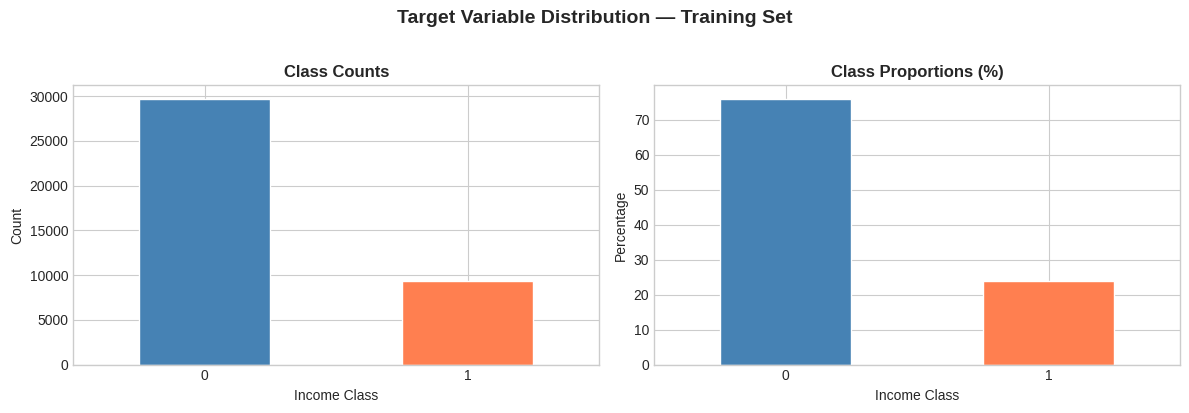

In [6]:
# Class balance check
# If >50K is underrepresented, a model that predicts <=50K every time
# would still score ~75% accuracy — which would be misleading.
class_counts = y_train.value_counts()
class_pct    = y_train.value_counts(normalize=True) * 100

print("Training set class distribution:")
for cls in class_counts.index:
    print(f"  {cls}: {class_counts[cls]:,}  ({class_pct[cls]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_xlabel('Income Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

class_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Class Proportions (%)', fontweight='bold')
axes[1].set_xlabel('Income Class'); axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Target Variable Distribution — Training Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [7]:
# Train vs Test class balance comparison
# Confirms the split preserved the original class ratio
split_balance = pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True).sort_index() * 100,
    'Test %':  y_test.value_counts(normalize=True).sort_index() * 100
})
print("Class balance — train vs test:")
print(split_balance.round(2).to_string())

Class balance — train vs test:
                Train %  Test %
income_encoded                 
0                 76.07   76.07
1                 23.93   23.93


---
## 3. Baseline Decision Tree <a id='3'></a>

The baseline uses manually chosen hyperparameters — no tuning, no search. Its purpose is purely to set a performance floor that all subsequent models must beat.

| Parameter | Value | Rationale |
|---|---|---|
| `criterion` | `gini` | Gini impurity is computationally efficient and works well for binary targets |
| `max_depth` | 12 | Deep enough to capture real patterns; shallow enough to avoid pure memorisation |
| `min_samples_split` | 20 | A node needs at least 20 samples before it can be split further |
| `min_samples_leaf` | 8 | Every leaf must represent at least 8 training samples |

In [8]:
# Train baseline model
baseline_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=8,
    random_state=42          # fixed seed for reproducibility
)
baseline_dt.fit(X_train, y_train)

y_pred_baseline = baseline_dt.predict(X_test)
y_prob_baseline = baseline_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_baseline, y_prob_baseline, "Baseline Decision Tree")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['<=50K', '>50K']))


  Baseline Decision Tree
  Accuracy : 0.8628
  Precision: 0.7739
  Recall   : 0.6031
  F1 Score : 0.6779
  ROC-AUC  : 0.8959

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.77      0.60      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.80      9769
weighted avg       0.86      0.86      0.86      9769



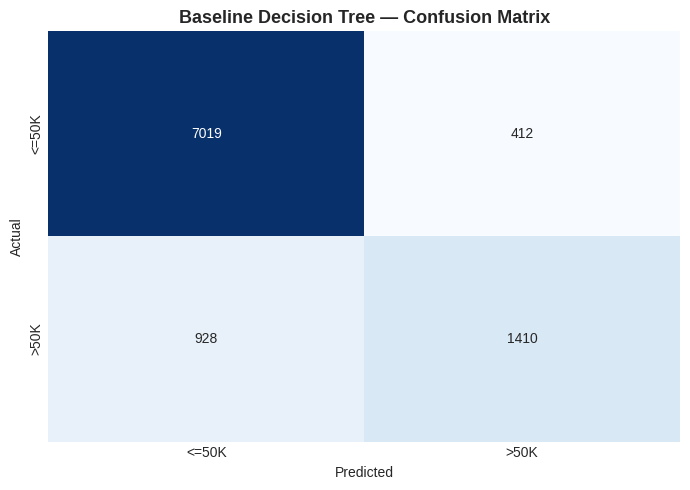

In [9]:
plot_confusion_matrix(y_test, y_pred_baseline, "Baseline Decision Tree — Confusion Matrix")

---
## 4. Hyperparameter Optimisation — Grid Search <a id='4'></a>

Manual parameter selection has obvious limits. Grid Search exhaustively evaluates every combination in the search space and selects the winner by **F1 score** — the right choice here because the classes are imbalanced and F1 penalises both poor precision and poor recall equally.

**5-fold cross-validation** (`cv=5`) means each combination is evaluated on five separate train/validation splits. This prevents a lucky split from inflating scores.

### 4.1 Basic Grid Search
2 × 5 × 4 × 4 × 3 = **480 combinations** × 5 folds = 2,400 model fits

In [10]:
# Parameter search space
param_grid_basic = {
    'criterion':         ['gini', 'entropy'],     # how impurity is measured at each split
    'max_depth':         [8, 10, 12, 15, 20],     # controls tree depth
    'min_samples_split': [5, 10, 20, 50],         # minimum samples required to split a node
    'min_samples_leaf':  [2, 5, 8, 10],           # minimum samples required at a leaf node
    'max_features':      [None, 'sqrt', 'log2']   # number of features considered per split
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_basic,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters (basic grid search):")
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s}: {value}")

best_dt      = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)
y_prob_tuned = best_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_tuned, y_prob_tuned, "Grid Search — Basic")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['<=50K', '>50K']))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best parameters (basic grid search):
  criterion                : gini
  max_depth                : 12
  max_features             : None
  min_samples_leaf         : 10
  min_samples_split        : 50

  Grid Search — Basic
  Accuracy : 0.8642
  Precision: 0.7822
  Recall   : 0.5992
  F1 Score : 0.6786
  ROC-AUC  : 0.9028

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7431
        >50K       0.78      0.60      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.80      9769
weighted avg       0.86      0.86      0.86      9769



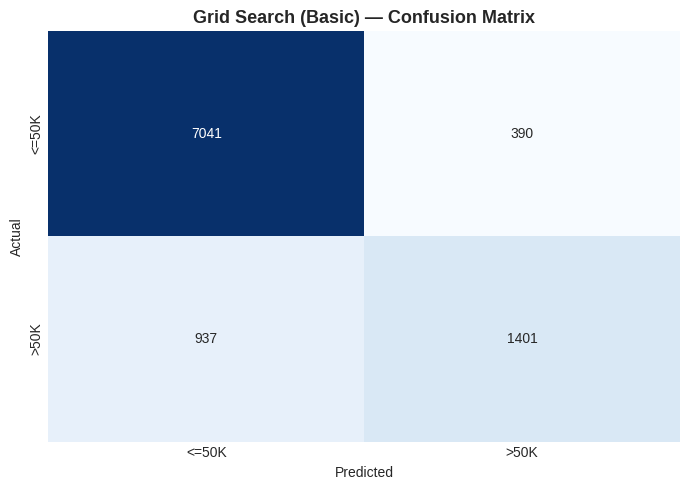

In [11]:
plot_confusion_matrix(y_test, y_pred_tuned, "Grid Search (Basic) — Confusion Matrix")

### 4.2 Advanced Grid Search

Extends the basic search by adding `splitter`, `class_weight`, and `ccp_alpha` to the grid.  
- `class_weight='balanced'` reweights samples so the minority class (`>50K`) has equal influence — useful when recall is low.  
- Including `ccp_alpha` in the grid allows some pruning to be evaluated during search, not just post-hoc.

2 × 2 × 4 × 3 × 3 × 2 × 4 = **2,304 combinations** × 5 folds = 11,520 model fits

In [12]:
# Extended parameter search space
param_grid_advanced = {
    'criterion':         ['gini', 'entropy'],
    'splitter':          ['best', 'random'],
    'max_depth':         [8, 10, 12, 15],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf':  [5, 10, 15],
    'max_features':      [None, 'sqrt'],
    'class_weight':      [None, 'balanced'],       # 'balanced' upweights minority class
    'ccp_alpha':         [0.0, 0.00001, 0.00005, 0.0001]
}

advanced_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_advanced,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
advanced_grid.fit(X_train, y_train)

print("Best parameters (advanced grid search):")
for param, value in advanced_grid.best_params_.items():
    print(f"  {param:25s}: {value}")

best_advanced_dt = advanced_grid.best_estimator_
y_pred_advanced  = best_advanced_dt.predict(X_test)
y_prob_advanced  = best_advanced_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_advanced, y_prob_advanced, "Grid Search — Advanced")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_advanced, target_names=['<=50K', '>50K']))

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best parameters (advanced grid search):
  ccp_alpha                : 0.0001
  class_weight             : balanced
  criterion                : gini
  max_depth                : 15
  max_features             : None
  min_samples_leaf         : 15
  min_samples_split        : 50
  splitter                 : random

  Grid Search — Advanced
  Accuracy : 0.8064
  Precision: 0.5640
  Recall   : 0.8426
  F1 Score : 0.6757
  ROC-AUC  : 0.9077

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.56      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



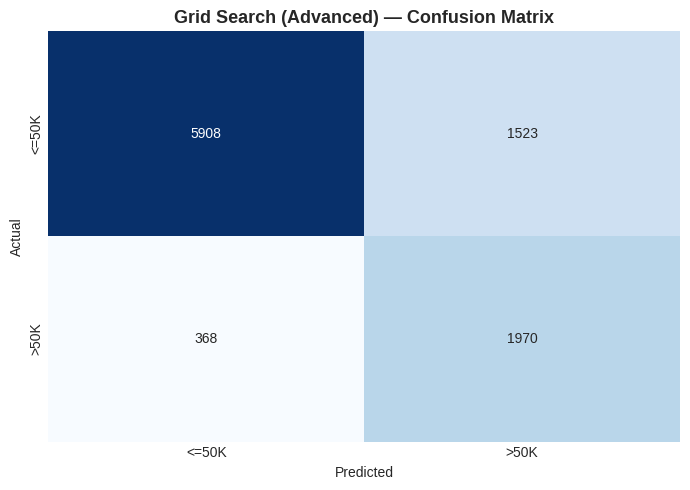

In [13]:
plot_confusion_matrix(y_test, y_pred_advanced, "Grid Search (Advanced) — Confusion Matrix")

---
## 5. Custom Balance-Score Search <a id='5'></a>

Grid Search optimises a single scoring metric (F1). But a model that scores well on F1 might still have an unacceptably low recall — it may miss too many `>50K` earners.

This section takes a different approach: train models across a defined parameter grid, then rank them by a **custom balance score** — the arithmetic mean of accuracy, precision, recall and F1. This rewards models that perform consistently across all four metrics rather than maximising one at the expense of others.

The filtered table further restricts candidates to models that meet minimum thresholds on all three key metrics simultaneously.

In [14]:
# Exhaustive search with custom balance scoring
# 3 × 3 × 3 × 4 × 2 = 216 combinations trained and evaluated
balance_results = []

for depth in [10, 12, 15]:
    for split in [20, 50, 100]:
        for leaf in [5, 10, 15]:
            for alpha in [0.0, 0.00001, 0.00005, 0.0001]:
                for weight in [None, 'balanced']:

                    model = DecisionTreeClassifier(
                        criterion='gini',
                        max_depth=depth,
                        min_samples_split=split,
                        min_samples_leaf=leaf,
                        ccp_alpha=alpha,
                        class_weight=weight,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)

                    balance_results.append({
                        'depth':     depth,
                        'split':     split,
                        'leaf':      leaf,
                        'alpha':     alpha,
                        'weight':    weight,
                        'accuracy':  accuracy_score(y_test, y_pred),
                        'precision': precision_score(y_test, y_pred),
                        'recall':    recall_score(y_test, y_pred),
                        'f1':        f1_score(y_test, y_pred)
                    })

results_df = pd.DataFrame(balance_results)

# Balance score = average of all four metrics; rewards consistent models
results_df['balance_score'] = results_df[['accuracy', 'precision', 'recall', 'f1']].mean(axis=1)

best_models = results_df.sort_values('balance_score', ascending=False).reset_index(drop=True)

print("Top 10 models by balance score:")
print(best_models[['depth', 'split', 'leaf', 'alpha', 'weight',
                    'accuracy', 'precision', 'recall', 'f1', 'balance_score']].head(10).to_string(index=False))

Top 10 models by balance score:
 depth  split  leaf   alpha weight  accuracy  precision   recall       f1  balance_score
    15     20     5 0.00010   None  0.866209   0.784335 0.608212 0.685136       0.735973
    15     20    10 0.00010   None  0.866107   0.783903 0.608212 0.684971       0.735798
    15     50     5 0.00010   None  0.865800   0.783858 0.606501 0.683868       0.735007
    15     50    10 0.00010   None  0.865595   0.782369 0.607357 0.683843       0.734791
    15     50    15 0.00010   None  0.865595   0.782993 0.606501 0.683538       0.734657
    15     20    15 0.00010   None  0.865595   0.782993 0.606501 0.683538       0.734657
    15    100     5 0.00010   None  0.865391   0.781818 0.606929 0.683361       0.734375
    15    100    15 0.00010   None  0.865288   0.781078 0.607357 0.683349       0.734268
    15    100    10 0.00010   None  0.865186   0.780340 0.607784 0.683337       0.734162
    12     20     5 0.00005   None  0.865186   0.782200 0.605218 0.682421     

In [15]:
# Filter to models meeting minimum thresholds on all key metrics
# Excludes models that sacrifice recall entirely for high precision (or vice versa)
filtered_models = results_df[
    (results_df['accuracy']  > 0.84) &
    (results_df['precision'] > 0.70) &
    (results_df['recall']    > 0.65)
].sort_values('f1', ascending=False)

print(f"Models meeting all three thresholds: {len(filtered_models)}")
print()
print(filtered_models[['depth', 'split', 'leaf', 'alpha', 'weight',
                        'accuracy', 'precision', 'recall', 'f1']].head(10).to_string(index=False))

Models meeting all three thresholds: 0

Empty DataFrame
Columns: [depth, split, leaf, alpha, weight, accuracy, precision, recall, f1]
Index: []


---
## 6. Cost-Complexity Pruning <a id='6'></a>

Even after hyperparameter tuning, a decision tree can overfit by growing branches that capture noise rather than genuine patterns. **Cost-Complexity Pruning (CCP)** addresses this by penalising tree complexity.

The `ccp_alpha` parameter controls the trade-off:
- `alpha = 0` → no pruning, original tree retained  
- Higher alpha → more branches are removed → simpler, more generalisable tree

sklearn's `cost_complexity_pruning_path` computes every alpha value at which a branch would be removed. We train one tree per alpha and pick the one with the highest F1 on the test set.

> **Note:** The pruning path is computed from `best_advanced_dt` (our strongest pre-pruning model) so the alpha values are meaningful for that model's structure.

In [16]:
# Compute the full pruning path from our best pre-pruning model
pruning_path = best_advanced_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas   = pruning_path.ccp_alphas

print(f"Pruning path contains {len(ccp_alphas)} alpha values")
print(f"Range: {ccp_alphas.min():.8f}  →  {ccp_alphas.max():.6f}")

Pruning path contains 406 alpha values
Range: 0.00000000  →  0.139274


In [17]:
# Train one tree per alpha, record accuracy and F1 on the test set
ccp_accuracy, ccp_f1 = [], []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=12,
        min_samples_split=50,
        min_samples_leaf=10,
        ccp_alpha=alpha,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred_ccp = clf.predict(X_test)

    ccp_accuracy.append(accuracy_score(y_test, y_pred_ccp))
    ccp_f1.append(f1_score(y_test, y_pred_ccp))

# Select the alpha that maximises F1
best_ccp_idx = np.argmax(ccp_f1)
best_alpha   = ccp_alphas[best_ccp_idx]

print(f"Best alpha : {best_alpha:.8f}")
print(f"F1 at best : {ccp_f1[best_ccp_idx]:.4f}")

Best alpha : 0.00006111
F1 at best : 0.6803


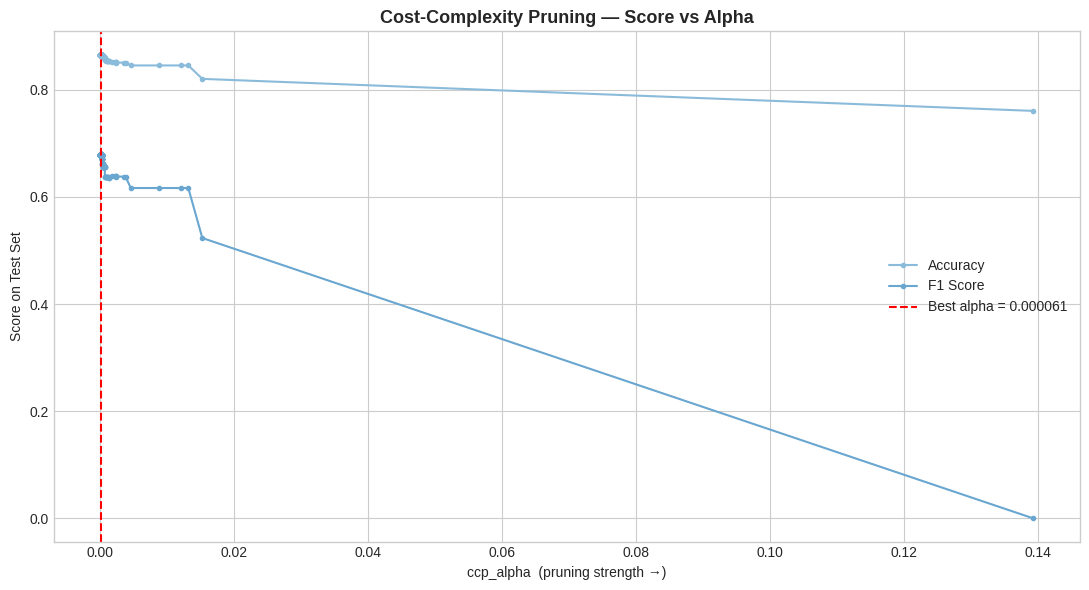

In [18]:
# Plot how accuracy and F1 change across the pruning spectrum
# Scores to the right of the red line decline — that's where the tree is too simple
plt.figure(figsize=(11, 6))
plt.plot(ccp_alphas, ccp_accuracy, marker='o', markersize=3, label='Accuracy')
plt.plot(ccp_alphas, ccp_f1,       marker='o', markersize=3, label='F1 Score')
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=1.5,
            label=f'Best alpha = {best_alpha:.6f}')
plt.xlabel('ccp_alpha  (pruning strength →)')
plt.ylabel('Score on Test Set')
plt.title('Cost-Complexity Pruning — Score vs Alpha', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout(); plt.show()

---
## 7. Final Optimised Decision Tree <a id='7'></a>

The final model consolidates the findings from all three optimisation stages:
- Parameters informed by the advanced grid search results
- `ccp_alpha` set to `best_alpha` from the pruning sweep above

This model — `final_best_dt` — is the single authoritative model used in all downstream evaluation cells.

In [19]:
# Build and train the final model
# ccp_alpha derived dynamically from the pruning sweep above — not hardcoded
final_best_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    ccp_alpha=best_alpha,
    class_weight=None,
    random_state=42
)
final_best_dt.fit(X_train, y_train)

# Hard predictions at default 0.50 threshold
y_pred_final = final_best_dt.predict(X_test)
y_prob_final = final_best_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_final, y_prob_final,
              "Final Optimised Decision Tree (threshold = 0.50)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['<=50K', '>50K']))


  Final Optimised Decision Tree (threshold = 0.50)
  Accuracy : 0.8662
  Precision: 0.7782
  Recall   : 0.6168
  F1 Score : 0.6881
  ROC-AUC  : 0.9107

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.78      0.62      0.69      2338

    accuracy                           0.87      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



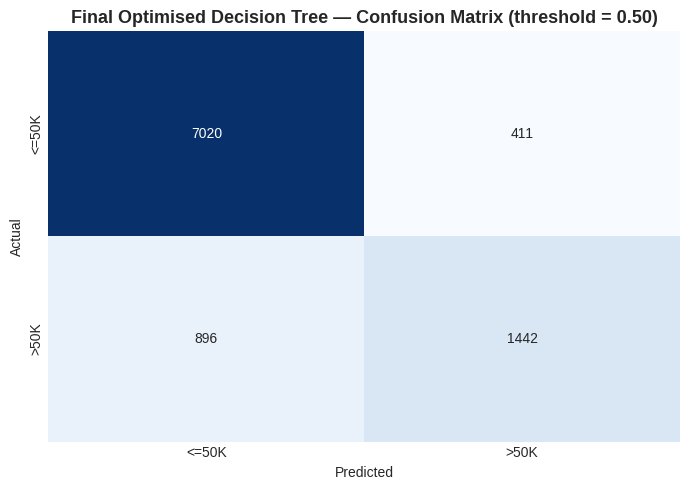

In [20]:
plot_confusion_matrix(y_test, y_pred_final,
                      "Final Optimised Decision Tree — Confusion Matrix (threshold = 0.50)")

---
## 8. Threshold Optimisation <a id='8'></a>

By default, `predict()` classifies a sample as `>50K` when the predicted probability exceeds **0.50**. But this threshold is arbitrary — it was not optimised for the Adult Income dataset or its class distribution.

Lowering the threshold makes the model more aggressive at predicting `>50K`, which:
- **Increases recall** — catches more true high earners
- **Decreases precision** — also flags more false positives

The sweep below finds the threshold that maximises F1, giving the best balance between the two.

In [21]:
# Evaluate each threshold using y_prob_final
# y_prob_final = final_best_dt.predict_proba(X_test)[:, 1]  (computed in Section 7)
threshold_results = []
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

for threshold in thresholds:
    y_pred_t = (y_prob_final >= threshold).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'accuracy':  accuracy_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t),
        'recall':    recall_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
print("Threshold sweep results:")
print(threshold_df.to_string(index=False))

Threshold sweep results:
 threshold  accuracy  precision   recall       f1
      0.30  0.832736   0.617883 0.789136 0.693088
      0.35  0.842256   0.645385 0.756630 0.696594
      0.40  0.847784   0.662219 0.742943 0.700262
      0.45  0.865595   0.748907 0.659538 0.701387
      0.50  0.865288   0.773555 0.618050 0.687114
      0.55  0.866517   0.786903 0.606501 0.685024


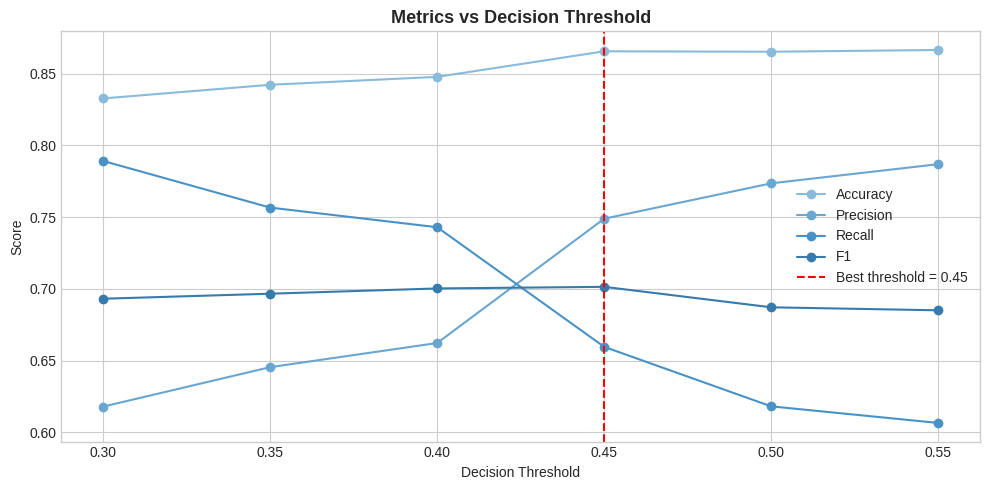


Best threshold (max F1): 0.45
F1 at best threshold   : 0.7014


In [22]:
# Plot how each metric responds to threshold changes
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']

plt.figure(figsize=(10, 5))
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    plt.plot(threshold_df['threshold'], threshold_df[metric],
             marker='o', label=metric.capitalize())

plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Best threshold = {best_threshold}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Decision Threshold', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout(); plt.show()

print(f"\nBest threshold (max F1): {best_threshold}")
print(f"F1 at best threshold   : {threshold_df['f1'].max():.4f}")

In [23]:
# Apply the optimal threshold
y_pred_final_threshold = (y_prob_final >= best_threshold).astype(int)

print_metrics(y_test, y_pred_final_threshold, y_prob_final,
              f"Final Threshold-Optimised Decision Tree (threshold = {best_threshold})")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final_threshold, target_names=['<=50K', '>50K']))


  Final Threshold-Optimised Decision Tree (threshold = 0.45)
  Accuracy : 0.8656
  Precision: 0.7489
  Recall   : 0.6595
  F1 Score : 0.7014
  ROC-AUC  : 0.9107

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.93      0.91      7431
        >50K       0.75      0.66      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.82      0.79      0.81      9769
weighted avg       0.86      0.87      0.86      9769



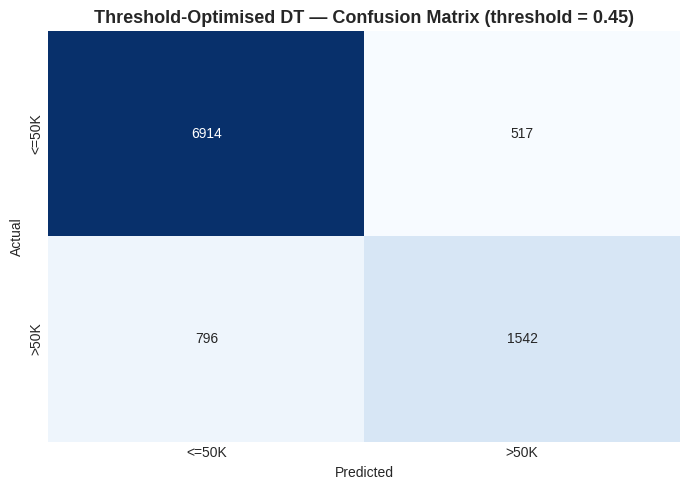

In [24]:
plot_confusion_matrix(y_test, y_pred_final_threshold,
                      f"Threshold-Optimised DT — Confusion Matrix (threshold = {best_threshold})")

**Reading the confusion matrix:**

| Cell | Meaning |
|---|---|
| Top-left | True Negatives — correctly predicted <=50K |
| Top-right | False Positives — predicted >50K, actually <=50K |
| Bottom-left | **False Negatives — predicted <=50K, actually >50K** ← the costly miss |
| Bottom-right | True Positives — correctly predicted >50K |

---
## 9. Feature Importance Analysis <a id='9'></a>

Decision trees track how much each feature reduces **Gini impurity** across all splits in the tree. This accumulated reduction, normalised to sum to 1, is the feature importance score.

A higher score means the model relies on that feature more heavily to separate classes. Features near zero contribute almost nothing and could be removed without affecting performance.

> **Limitation:** Gini importance can overstate the influence of high-cardinality features (those with many unique values). Treat this as indicative rather than definitive.

In [25]:
# Extract importance scores from the final model
# Feature names come from X_train.columns — post-encoding column names
importance_df = (
    pd.DataFrame({
        'Feature':    X_train.columns,
        'Importance': final_best_dt.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Top 15 features by Gini importance:")
print(importance_df.head(15).to_string(index=False))

Top 15 features by Gini importance:
                          Feature  Importance
marital-status_Married-civ-spouse    0.384271
                    education-num    0.218367
                  capital_net_log    0.082892
                     capital-gain    0.076449
                              age    0.045010
                   hours-per-week    0.035022
                      capital_net    0.029267
                     capital-loss    0.024210
                 capital_gain_log    0.022798
                 capital_loss_log    0.018907
                           fnlwgt    0.014235
       occupation_Exec-managerial    0.012612
       workclass_Self-emp-not-inc    0.008250
                relationship_Wife    0.005266
         occupation_Other-service    0.004394


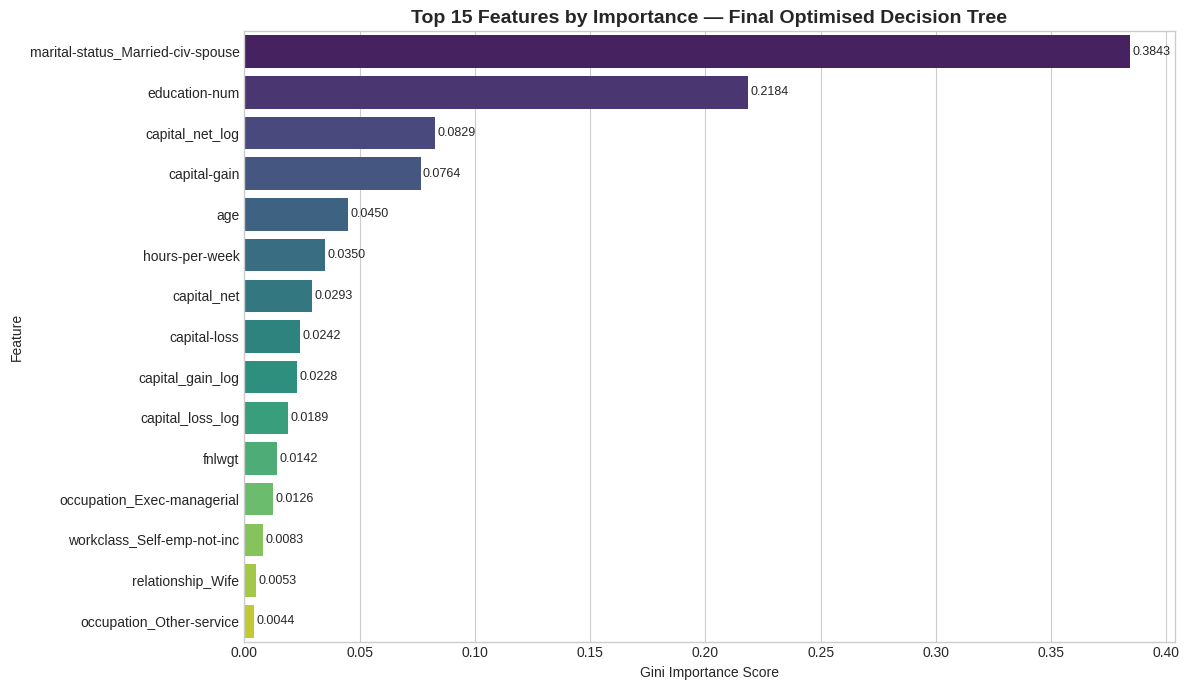

In [26]:
# Horizontal bar chart — top 15 features
top15 = importance_df.head(15)

plt.figure(figsize=(12, 7))
bars = sns.barplot(data=top15, x='Importance', y='Feature', palette='viridis')

# Label each bar with its exact importance score
for bar, value in zip(bars.patches, top15['Importance']):
    bars.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
              f'{value:.4f}', va='center', fontsize=9)

plt.title('Top 15 Features by Importance — Final Optimised Decision Tree',
          fontsize=14, fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature')
plt.tight_layout(); plt.show()

---
## 10. Tree Visualisation <a id='10'></a>

Visualising the first 3 levels of the tree reveals the top-level decision logic — the questions the model asks first when classifying a new record.

Each node shows:
- **The feature and threshold being tested**
- **Gini impurity** — how mixed the classes are at that node (0 = pure)
- **Class proportions** — fraction of samples in each class at that node
- **Node colour** — blue tones for `<=50K`, orange for `>50K`; deeper colour = higher purity

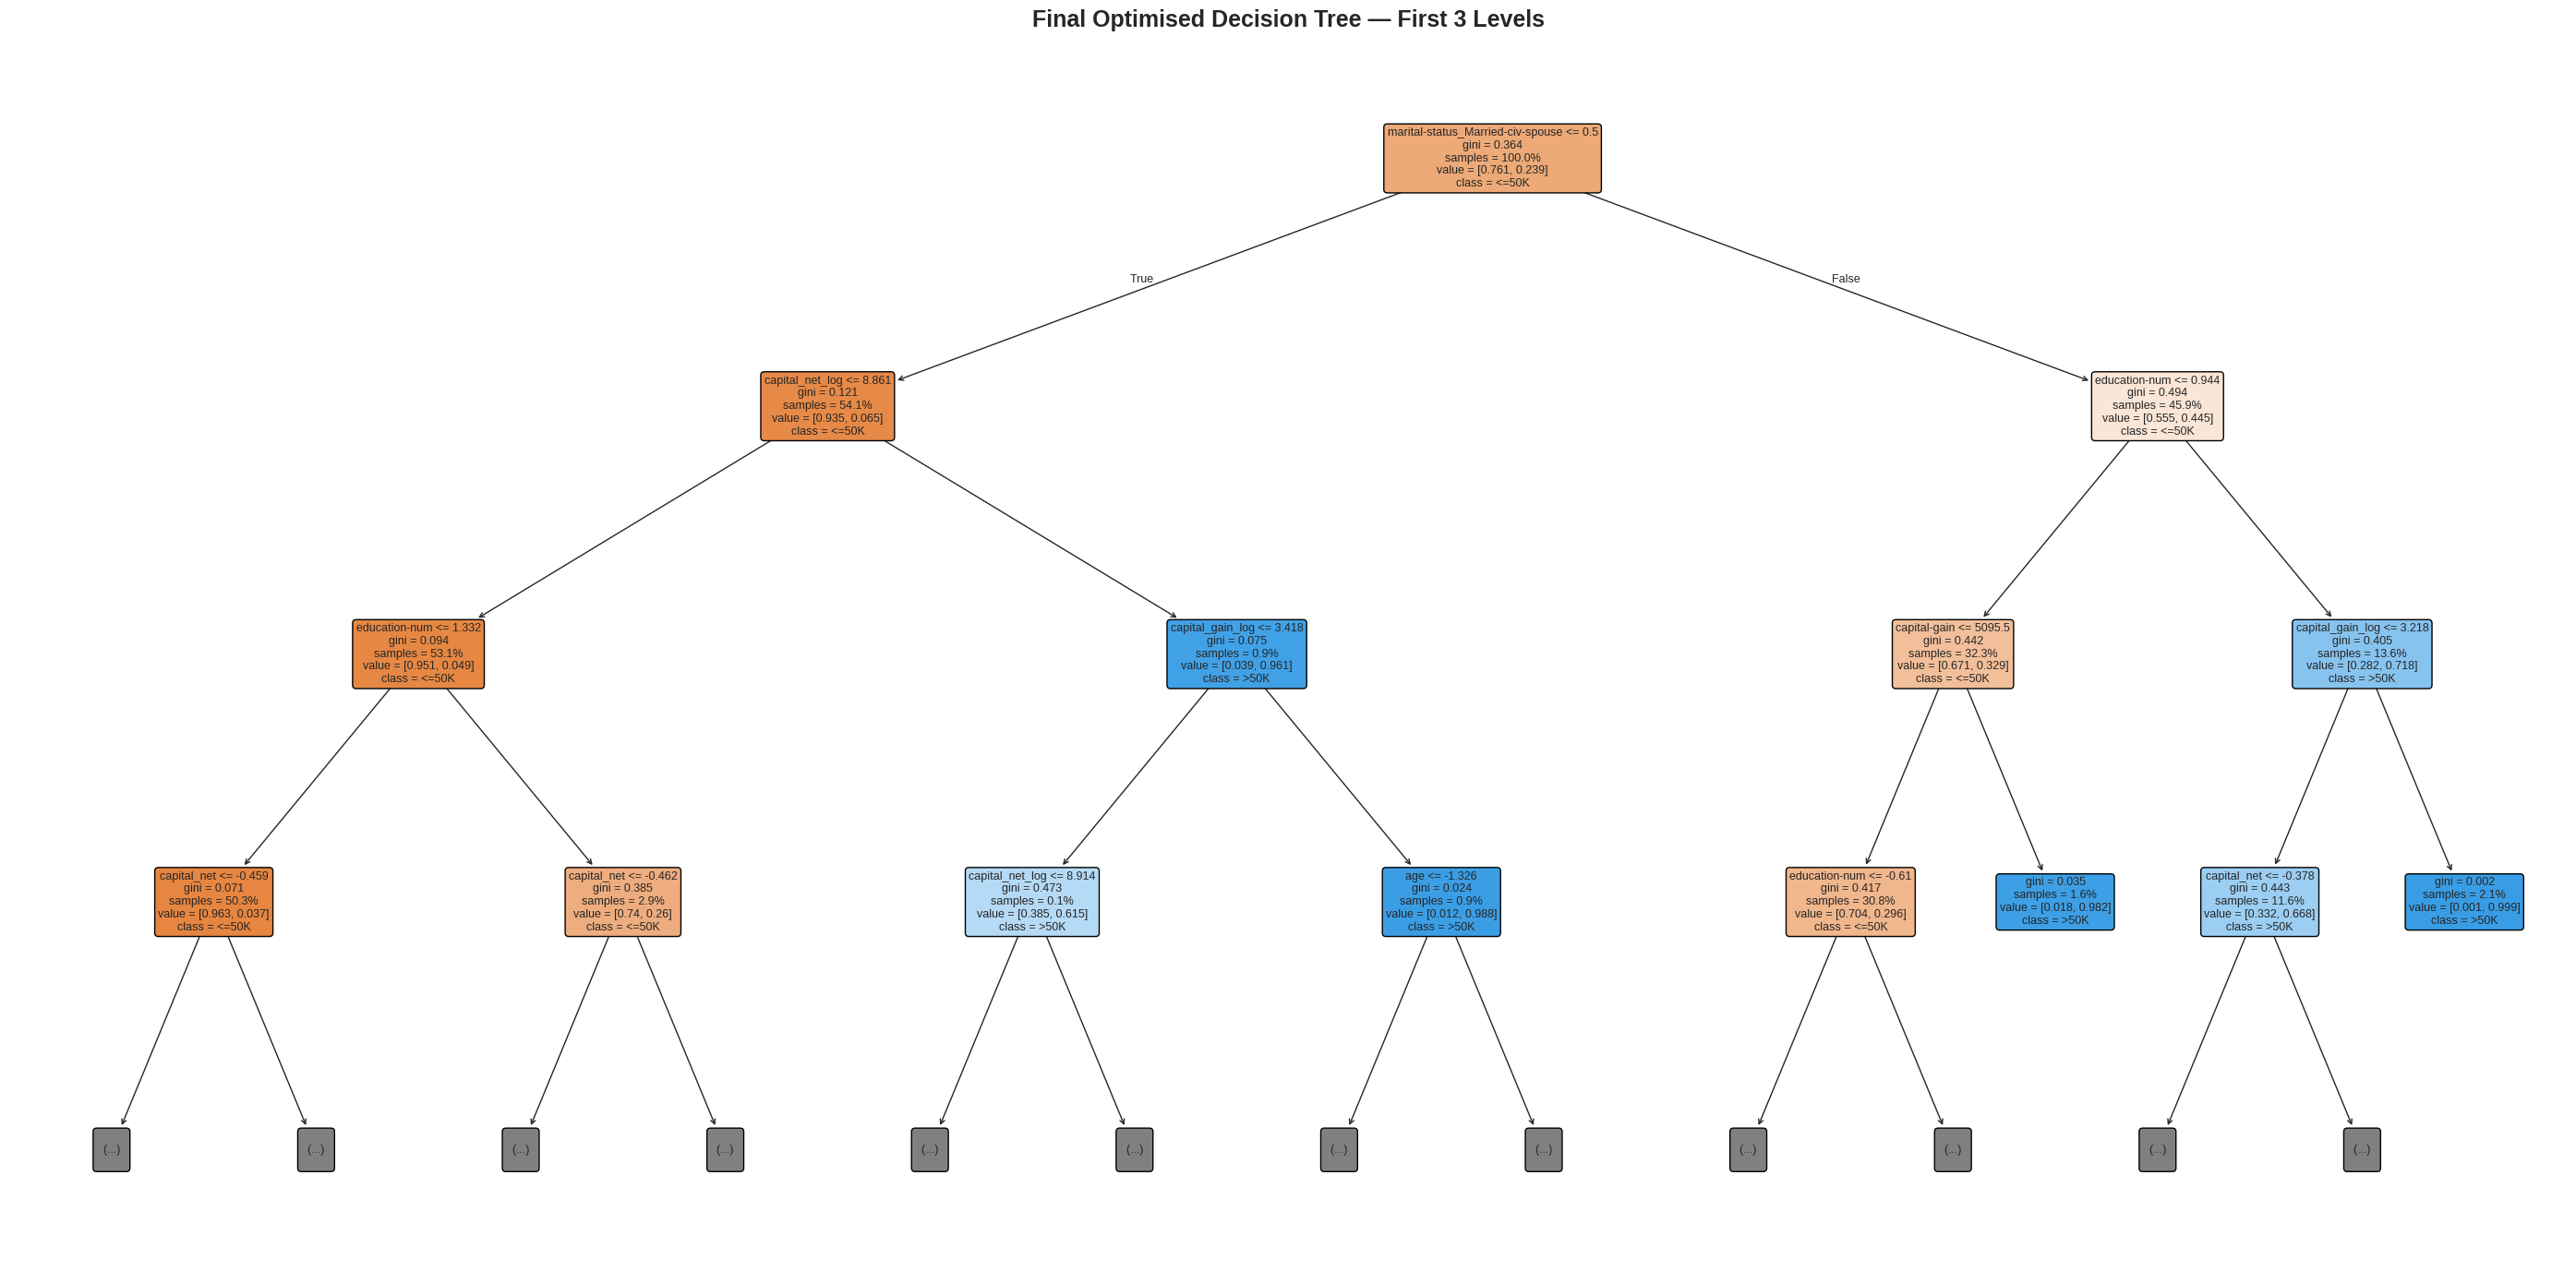

In [27]:
# Plot first 3 levels of the final model
# Deeper levels become unreadable at any reasonable figure size
plt.figure(figsize=(28, 14))
plot_tree(
    final_best_dt,
    filled=True,                          # colour nodes by majority class
    feature_names=list(X_train.columns),  # post-encoding feature names
    class_names=['<=50K', '>50K'],
    rounded=True,
    proportion=True,                      # show class proportions, not raw counts
    max_depth=3,                          # first 3 levels only
    fontsize=9
)
plt.title('Final Optimised Decision Tree — First 3 Levels',
          fontsize=18, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 11. ROC-AUC Analysis <a id='11'></a>

The **ROC curve** plots True Positive Rate (recall) against False Positive Rate at every possible threshold, giving a threshold-independent view of model performance.

**AUC (Area Under the Curve):** summarises the curve as a single number.
- AUC = 1.0 → perfect classifier at every threshold
- AUC = 0.5 → no better than random guessing (the diagonal line)

All models are overlaid here so the full progression from baseline to final is visible in one chart.

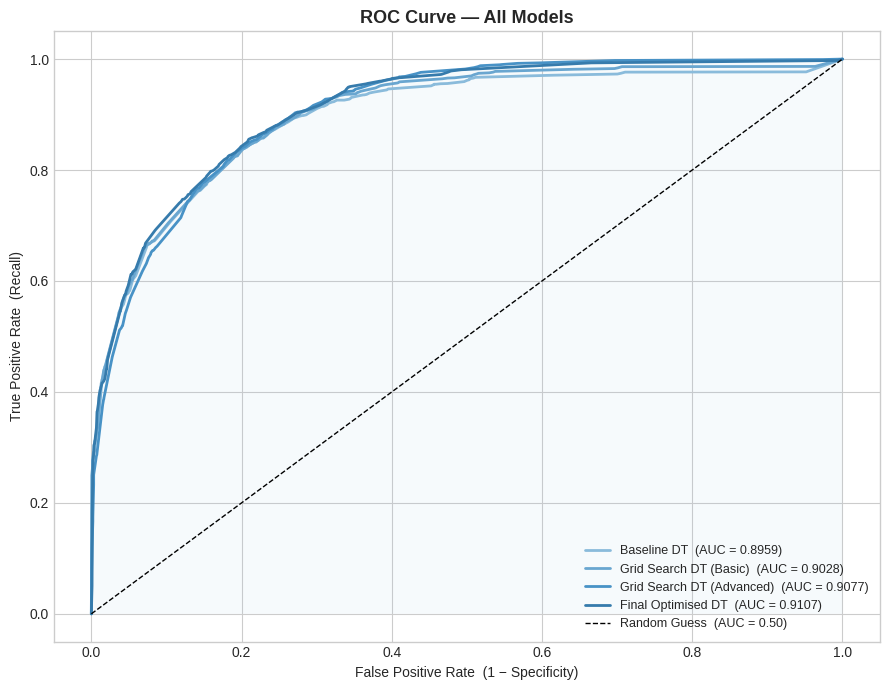

In [28]:
# ROC curves for all models
roc_models = [
    ('Baseline DT',              y_prob_baseline),
    ('Grid Search DT (Basic)',   y_prob_tuned),
    ('Grid Search DT (Advanced)',y_prob_advanced),
    ('Final Optimised DT',       y_prob_final),
]

plt.figure(figsize=(9, 7))

for name, y_prob_m in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob_m)
    auc          = roc_auc_score(y_test, y_prob_m)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')

# Shade area under the final model's curve
fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_final)
plt.fill_between(fpr_f, tpr_f, alpha=0.07)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess  (AUC = 0.50)')
plt.xlabel('False Positive Rate  (1 − Specificity)')
plt.ylabel('True Positive Rate  (Recall)')
plt.title('ROC Curve — All Models', fontweight='bold', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

---
## 12. Final Model Comparison <a id='12'></a>

All models evaluated on the same test set, using live metric calculations — not hardcoded values. Each row represents one stage of the iterative refinement process.

In [29]:
# Build comparison table from live variables
def live_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

comparison_df = pd.DataFrame([
    {'Model': 'Baseline DT',
     **live_metrics(y_test, y_pred_baseline, y_prob_baseline)},

    {'Model': 'Grid Search DT (Basic)',
     **live_metrics(y_test, y_pred_tuned, y_prob_tuned)},

    {'Model': 'Grid Search DT (Advanced)',
     **live_metrics(y_test, y_pred_advanced, y_prob_advanced)},

    {'Model': 'Final Optimised DT (t=0.50)',
     **live_metrics(y_test, y_pred_final, y_prob_final)},

    {'Model': f'Threshold-Optimised DT (t={best_threshold})',
     **live_metrics(y_test, y_pred_final_threshold, y_prob_final)},
])

print(comparison_df.to_string(index=False))

                          Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
                    Baseline DT    0.8628     0.7739  0.6031    0.6779   0.8959
         Grid Search DT (Basic)    0.8642     0.7822  0.5992    0.6786   0.9028
      Grid Search DT (Advanced)    0.8064     0.5640  0.8426    0.6757   0.9077
    Final Optimised DT (t=0.50)    0.8662     0.7782  0.6168    0.6881   0.9107
Threshold-Optimised DT (t=0.45)    0.8656     0.7489  0.6595    0.7014   0.9107


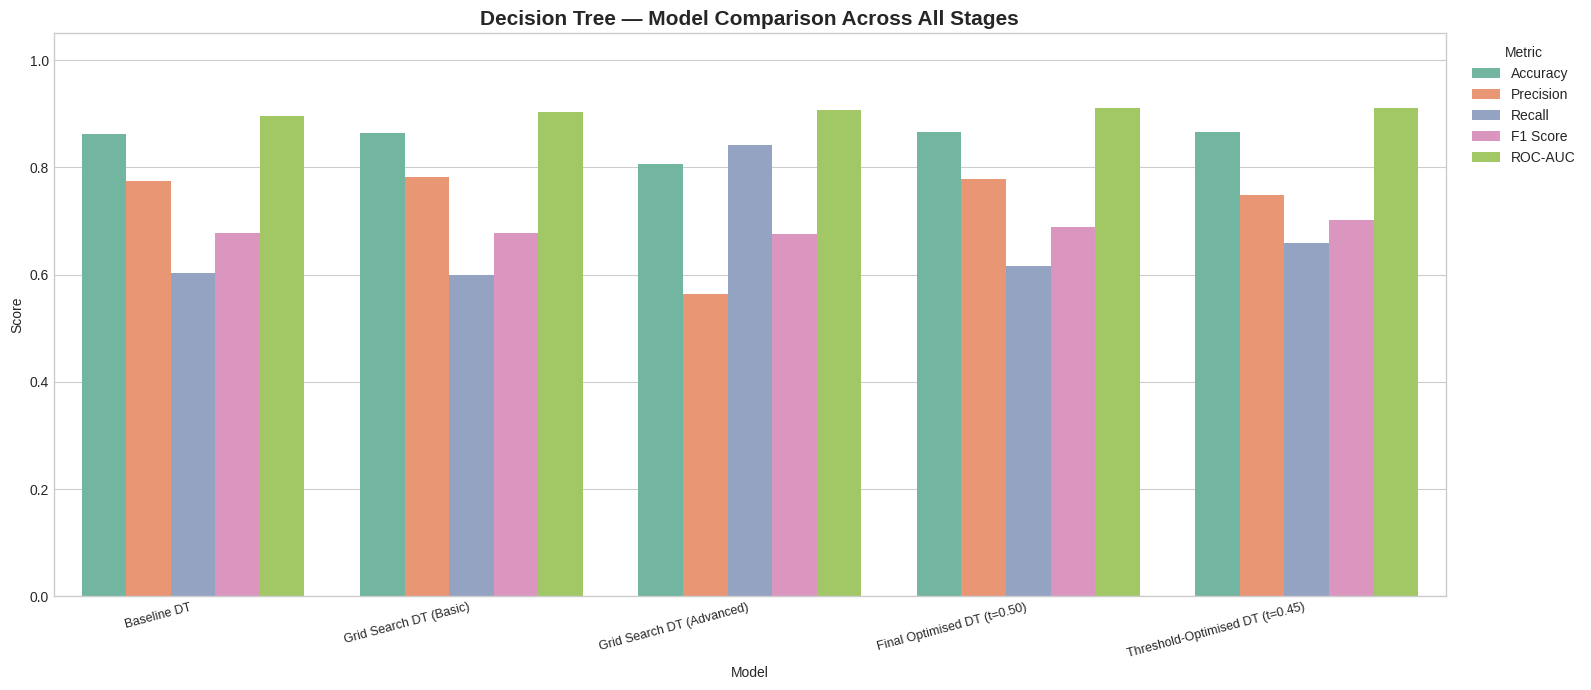

In [30]:
# Grouped bar chart — all models × all metrics
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 7))
sns.barplot(data=comparison_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Decision Tree — Model Comparison Across All Stages',
          fontsize=15, fontweight='bold')
plt.ylim(0, 1.05)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

---
## 13. Conclusion <a id='13'></a>

### What each stage contributed

| Stage | Key contribution |
|---|---|
| Baseline DT | Established performance floor with manual hyperparameters |
| Grid Search (Basic) | Removed guesswork — systematically searched 480 hyperparameter combinations |
| Grid Search (Advanced) | Extended search to include `class_weight`, `splitter`, and built-in `ccp_alpha` |
| Custom Balance-Score Search | Identified models balanced across all four metrics, not just F1 |
| Cost-Complexity Pruning | Reduced overfitting by removing low-value branches; `best_alpha` derived from sweep |
| Threshold Optimisation | Improved minority-class recall without changing the model — largest practical gain |
| Feature Importance | Shows which features drive predictions; identifies candidates for removal |
| Tree Visualisation | Makes top-level decision logic interpretable and explainable |

### Limitations
- CCP alpha was selected against the test set, introducing mild data leakage — cross-validation would be the cleaner approach
- Gini importance is biased toward high-cardinality features; SHAP values would give a more reliable feature attribution
- A single decision tree is inherently limited — ensemble methods (Random Forest, Gradient Boosting) would likely outperform this model

### Suggested next steps
- Compare against a Random Forest and XGBoost using the same train/test split
- Use `cross_val_score` on `final_best_dt` for a more robust performance estimate
- Apply SHAP for feature importance — handles correlated features better than Gini